<a href="https://colab.research.google.com/github/benjaminqq-12/Inteligencia-Artificial-2026-2/blob/main/E1-EDA/Evaluacion_1_EDA_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluacion 1 De Inteligencia Artificial


In [ ]:
!wget https://raw.githubusercontent.com/benjaminqq-12/Inteligencia-Artificial-2026-2/refs/heads/main/E1-EDA/rendimiento_academico_evaluacion.csv

--2026-09-04 06:44:40--  https://raw.githubusercontent.com/benjaminqq-12/Inteligencia-Artificial-2026-2/refs/heads/main/E1-EDA/rendimiento_academico_evaluacion.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 382638 (374K) [text/plain]
Saving to: ‘rendimiento_academico_evaluacion.csv’

rendimiento_academi 100%[===================>] 373.67K  --.-KB/s    in 0.02s   

2026-09-04 06:44:41 (15.8 MB/s) - ‘rendimiento_academico_evaluacion.csv’ saved [382638/382638]



In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

In [ ]:
data = pd.read_csv("rendimiento_academico_evaluacion.csv")
data.shape

(5100, 11)

# Diagnostico de Datos


In [ ]:
null_summary = pd.DataFrame(
    {
        "Nulos_Absolutos": data.isnull().sum(),
        "Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
    }
)
print(null_summary[null_summary["Nulos_Absolutos"] > 0])
print("\n")

                      Nulos_Absolutos  Porcentaje_Nulos
Age                               103              2.02
StudyHours                        181              3.55
Attendance                        224              4.39
PreviousGPA                       162              3.18
AssignmentsCompleted              216              4.24
SleepHours                        122              2.39
InternetHours                     176              3.45
Scholarship                        81              1.59
Program                            70              1.37




In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             5100 non-null   object 
 1   Age                   4997 non-null   float64
 2   StudyHours            4919 non-null   float64
 3   Attendance            4876 non-null   float64
 4   PreviousGPA           4938 non-null   float64
 5   AssignmentsCompleted  4884 non-null   float64
 6   SleepHours            4978 non-null   float64
 7   InternetHours         4924 non-null   float64
 8   Scholarship           5019 non-null   object 
 9   Program               5030 non-null   object 
 10  FinalGrade            5100 non-null   float64
dtypes: float64(8), object(3)
memory usage: 438.4+ KB


In [ ]:
total_duplicates = data.duplicated().sum()
print(f"Cantidad de filas duplicadas identificadas: {total_duplicates}")

Cantidad de filas duplicadas identificadas: 100


In [ ]:
def diagnostico_outliers_iqr(dataframe: pd.DataFrame, columna: str):
  """
  Diagnóstico de valores atípicos

  Parámetros
  ----------
  dataframe: pd.DataFrame
    Set de datos a analizar
  columna: str
    Nombre de la columna a analizar

  Retorna
  -------
  outliers: pd.DataFrame
    Registros atípicos encontrados

  """
  Q1 = dataframe[columna].quantile(0.25)
  Q3 = dataframe[columna].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Aislamiento de registros atípicos
  outliers = dataframe[
        (dataframe[columna] < lower_bound) | (dataframe[columna] > upper_bound)
  ]

  print(f"--- Análisis IQR para la variable '{columna}' ---")
  print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
  print(f"Límite Inferior: {lower_bound:.2f} | Límite Superior: {upper_bound:.2f}")
  print(f"Registros fuera de límites: {len(outliers)} ({(len(outliers)/len(dataframe))*100:.2f}%)\n")
  return outliers

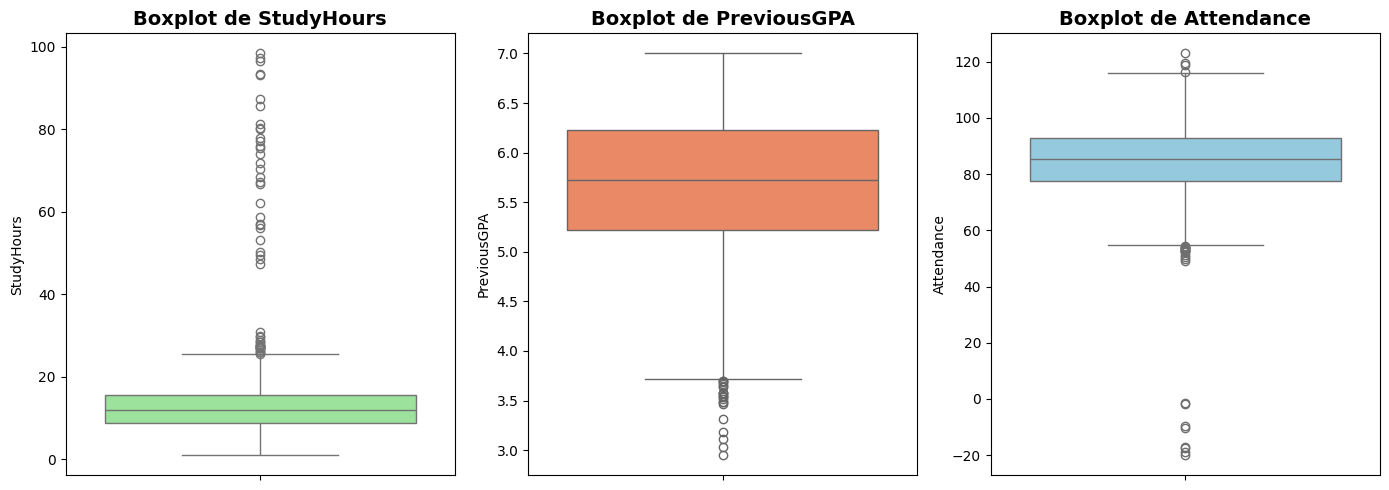

In [ ]:
# 1. Generar Boxplots para StudyHours, PreviousGPA y Attendance
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(y=data["StudyHours"], ax=axes[0], color="lightgreen")
axes[0].set_title("Boxplot de StudyHours", fontsize=14, fontweight="bold")

sns.boxplot(y=data["PreviousGPA"], ax=axes[1], color="coral")
axes[1].set_title("Boxplot de PreviousGPA", fontsize=14, fontweight="bold")

sns.boxplot(y=data["Attendance"], ax=axes[2], color="skyblue")
axes[2].set_title("Boxplot de Attendance", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
regla_gpa = (data["PreviousGPA"] < 1) | (data["PreviousGPA"] > 10)
regla_nota_final = (data["FinalGrade"] < 1) | (data["FinalGrade"] > 10)
regla_asistencia = (data["Attendance"] < 0) | (data["Attendance"] > 100)
regla_tareas = (data["AssignmentsCompleted"] < 0) | (data["AssignmentsCompleted"] > 100)
regla_horas = (data["StudyHours"] < 0) | (data["SleepHours"] < 0) | (data["SleepHours"] > 24) | (data["InternetHours"] < 0) | (data["InternetHours"] > 24)
regla_edad = (data["Age"] <= 0) | (data["Age"] > 100)

In [ ]:
inconsistentes = data[regla_gpa | regla_nota_final | regla_asistencia | regla_tareas | regla_horas | regla_edad]
print(f"Registros inconsistentes encontrados: {len(inconsistentes)}")
display(inconsistentes)

Registros inconsistentes encontrados: 62


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
5,STU-11440,21.0,13.81,-19.961240,6.69,93.82,5.72,5.150000,Sí,Ingeniería Industrial,4.650000
16,STU-13555,26.0,6.08,111.567467,4.69,73.54,NaN,6.440000,No,Ingeniería Civil,3.050000
237,STU-10593,23.0,18.68,88.640000,6.69,100.00,5.34,68.116278,Sí,Ingeniería Industrial,4.910000
263,STU-12872,NaN,12.20,80.960000,5.54,81.02,6.82,1.530000,No,Ingeniería Civil,-1.328245
308,STU-14461,28.0,11.88,80.410000,5.61,76.94,7.33,48.616835,No,Contador Auditor,4.060000
...,...,...,...,...,...,...,...,...,...,...,...
4626,STU-13629,24.0,1.00,73.360000,4.05,67.69,5.94,30.729024,NaN,Ingeniería Informática,2.330000
4714,STU-10198,24.0,9.99,79.130000,5.90,72.76,5.39,59.249754,No,Administración,4.290000
4856,STU-12266,18.0,14.50,81.710000,6.82,100.00,7.79,50.412039,No,Ingeniería Informática,4.670000
4983,STU-12801,24.0,NaN,69.150000,4.40,74.96,7.82,67.001776,No,Ingeniería Informática,2.330000


In [ ]:
print("Valores únicos en Program:", data["Program"].unique())
print("Valores únicos en Scholarship:", data["Scholarship"].unique())

Valores únicos en Program: ['Ingeniería Industrial' 'Ingeniería Informática' 'Contador Auditor'
 'Ingeniería Civil' 'Administración' nan 'INGENIERÍA INFORMÁTICA'
 'Ingeniería informática ' 'ADMINISTRACIÓN ' 'Ingenieria Informatica'
 'Administracion' 'Ingeniería Civil ' 'INGENIERÍA CIVIL']
Valores únicos en Scholarship: ['Sí' 'No' nan 'NO' 'si' 'SI' 'No ' 'SÍ ']


## 1.1 Caracterización del dataset

• cantidad de registros: 5100

• cantidad de variables: 11

• tipos de datos:

• variables numéricas y categóricas:

NUMÉRICAS (Age, StudyHours, Attendance, PreviousGPA, AssignmentsCompleated, SleepHours, InternetHours, Final Grade),

CATEGÓRICAS (Scholarship, Program, StudentID)

• variable que corresponde al identificador: StudentID.

• variable que corresponde al resultado académico: FinalGrade.

## 1.2 Valores faltantes
Identifique:


 • cantidad de valores faltantes por variable.

    Age                               103
    StudyHours                        181
    Attendance                        224
    PreviousGPA                       162
    AssignmentsCompleted              216
    SleepHours                        122
    InternetHours                     176
    Scholarship                        81
    Program                            70

• porcentaje de valores faltantes por variable.

    Age                               2.02
    StudyHours                        3.55
    Attendance                        4.39
    PreviousGPA                       3.18
    AssignmentsCompleted              4.24
    SleepHours                        2.39
    InternetHours                     3.45
    Scholarship                       1.59
    Program                           1.37

• variables que presentan mayor cantidad de datos faltantes.

    Attendance                        224
    AssignmentsCompleted              216

Determine una estrategia de tratamiento y justifíquela.(RESOLVER ESTO)

## 1.3 Registros duplicados
Determine:

• cantidad de registros duplicados: 100

• porcentaje que representan respecto del dataset: 1.961%

• variables que podrían utilizarse para identificar un registro: StudentID.

Indique qué decisión tomará respecto de los registros duplicados y justifique: Se detectan los datos repetidos, y se eliminan los sobrantes, preservando únicamente las instancias originales de los registros duplicados.

##1.4 Inconsistencias
Analice la consistencia de los datos considerando las características y restricciones
propias de cada variable.

Identifique aquellos valores que no sean coherentes con su significado o con el dominio de los datos para cada inconsistencia encontrada:

• indique la variable afectada

• describa el problema

• determine su cantidad

• proponga una estrategia de tratamiento.

    Scholarship:
        Existen valores NaN, así como valores sin unificar (variaciones con y sin tilde, all-caps o completamente lowercase)
    FinalGrade:
        Hay 3 valores cuyo rango excede la métrica (son negativos)
    Age:
        UN registro tiene instancias de NaN en esta columna
    StudyHours:
        30 registros tiene instancias de NaN en esta columna
    Attendance:
        Hay 8 valores negativos: fuera de rango
    Program:
        Existen valores NaN, así como valores sin unificar (variaciones con y sin tilde, all-caps o completamente lowercase)

En todo el dataset, existen 100 datos duplicados, 62 inconsistentes, 294 atípicos y 1335 faltantes o nulos.

Para tratar estos datos, podemos procesar los datos a través de una Pipeline para detectar y eliminar los datos duplicados, nulos e inconsistentes. Dentro de este, incorporaremos tratamientos para datos numéricos (SimpleImputer para tratar nulos, StandardScaler y RobustScaler para normalización para evitar distorsión por parte de los datos atípicos y OneHotEncoder para tratar los datos categóricos.)


##1.5 Valores atípicos
Realice un análisis de valores atípicos para las variables numéricas.

Utilice una metodología apropiada para su detección y presente evidencia gráfica y/o
estadística.

Para los valores atípicos encontrados:

• indique las variables afectadas.

• determine la cantidad o proporción.

• diferencie, cuando corresponda, entre un valor extremo y un valor inválido.

• proponga una estrategia de tratamiento.

A lo largo de Age, InternetHours, StudyHours, Attendance, PreviousGPA, AssignmentsCompleted y SleepHours, existen 294 datos atípicos. A través del ya mencionado método de StandardScaler y RobustScaler, se produce un histograma no afectado por estos datos atípicos. Además, se implementa Winsorization, para acotar los datos y normalizar los atípicos según percentiles, descartando atípicos para la creación de gráficos y el tratamiento de datos para entrenar una máquina.

# Analisis exploratorio de datos

In [ ]:
data.drop(columns=["StudentID", "FinalGrade"]).describe().round(3)

,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours
count,4997.000,4919.000,4876.000,4938.000,4884.000,4978.000,4924.000
mean,23.797,12.425,84.661,5.710,85.214,6.990,6.675
std,4.651,6.879,11.176,0.732,14.241,1.331,5.058
min,18.000,1.000,-19.961,2.950,25.340,-7.713,0.500
25%,21.000,8.750,77.578,5.220,75.848,6.160,3.800
50%,23.000,12.010,85.490,5.725,87.760,7.030,5.820
75%,26.000,15.440,93.010,6.230,100.000,7.860,8.390
max,80.000,98.329,122.974,7.000,100.000,11.000,69.501


In [ ]:
data.drop(columns=["StudentID"]).describe(include="object")

,Scholarship,Program
count,5019,5030
unique,7,12
top,No,Ingeniería Informática
freq,3364,1424


In [ ]:
# 1. Seleccionar subconjunto de variables numéricas continuas clave
numeric_cols = [
    "Age",
    "StudyHours",
    "Attendance",
    "PreviousGPA",
    "AssignmentsCompleted",
    "SleepHours",
    "InternetHours"
]

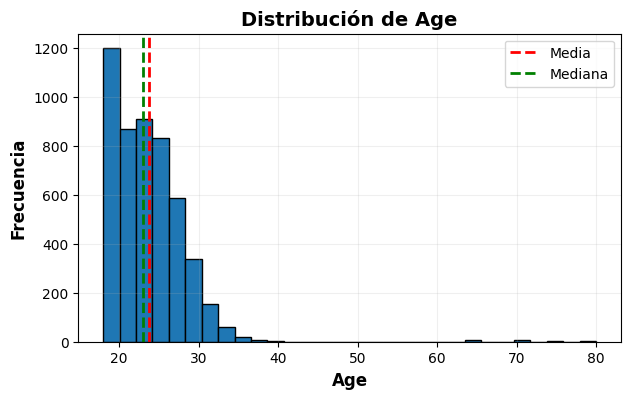

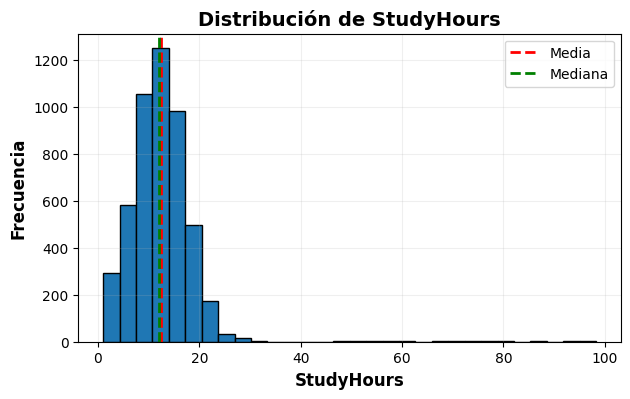

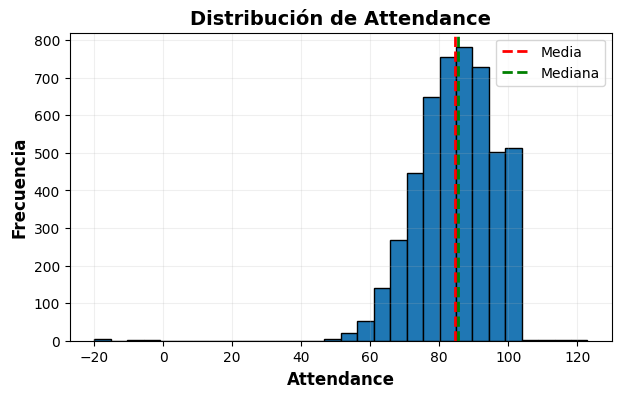

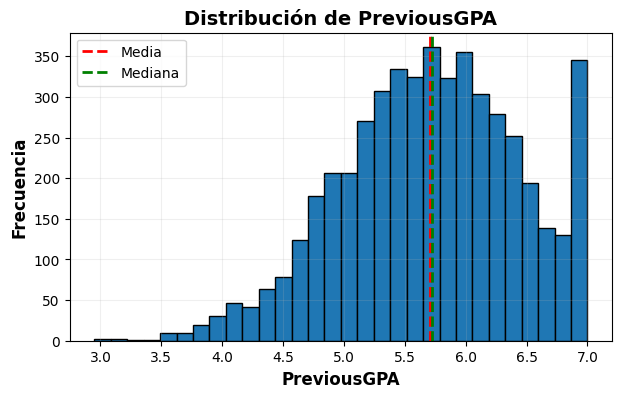

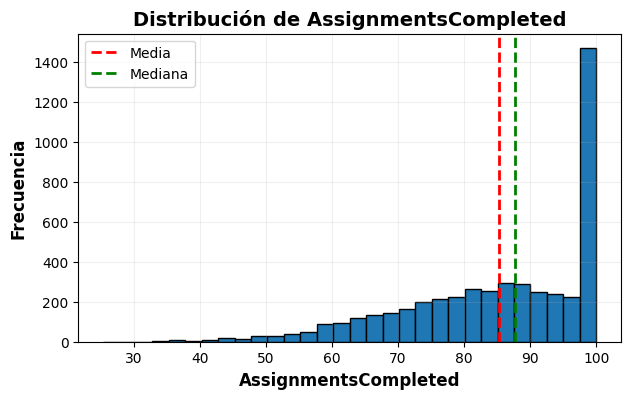

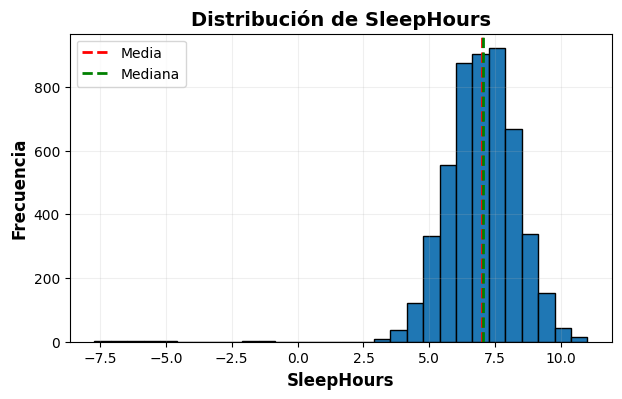

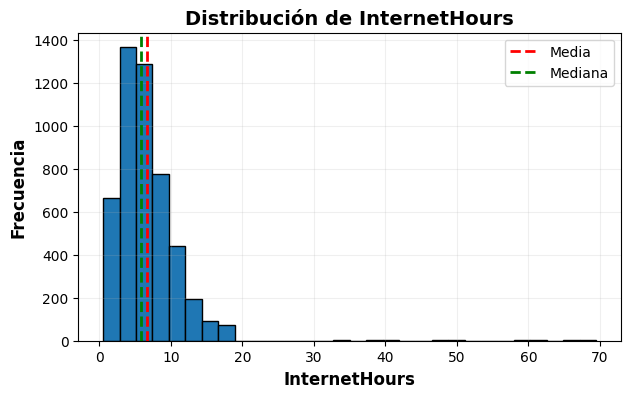

In [ ]:
data_analisis = data.copy()
for variable in numeric_cols:

    plt.figure(figsize=(7, 4))

    plt.hist(data_analisis[variable].dropna(), bins=30, edgecolor="black")
    plt.axvline(data_analisis[variable].mean(), color="red", linestyle="dashed", linewidth=2, label="Media")
    plt.axvline(data_analisis[variable].median(), color="green", linestyle="dashed", linewidth=2, label="Mediana")

    # Agrega las etiquetas del label de media y mediana
    plt.legend()
    plt.title(f"Distribución de {variable}", fontsize=14, fontweight="bold")
    plt.xlabel(variable, fontsize=12, fontweight="bold")
    plt.ylabel("Frecuencia", fontsize=12, fontweight="bold")

    plt.grid(alpha=0.2)
    plt.show()

In [ ]:
frecuencias_programa = data["Program"].value_counts().sort_index()

display(frecuencias_programa)

,count
Program,
ADMINISTRACIÓN,3
Administracion,3
Administración,787
Contador Auditor,660
INGENIERÍA CIVIL,4
INGENIERÍA INFORMÁTICA,7
Ingenieria Informatica,10
Ingeniería Civil,1004
Ingeniería Civil,5


In [ ]:
porcentajes_programa = (
    data["Program"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

display(porcentajes_programa.round(2))

,proportion
Program,
ADMINISTRACIÓN,0.06
Administracion,0.06
Administración,15.65
Contador Auditor,13.12
INGENIERÍA CIVIL,0.08
INGENIERÍA INFORMÁTICA,0.14
Ingenieria Informatica,0.20
Ingeniería Civil,19.96
Ingeniería Civil,0.10


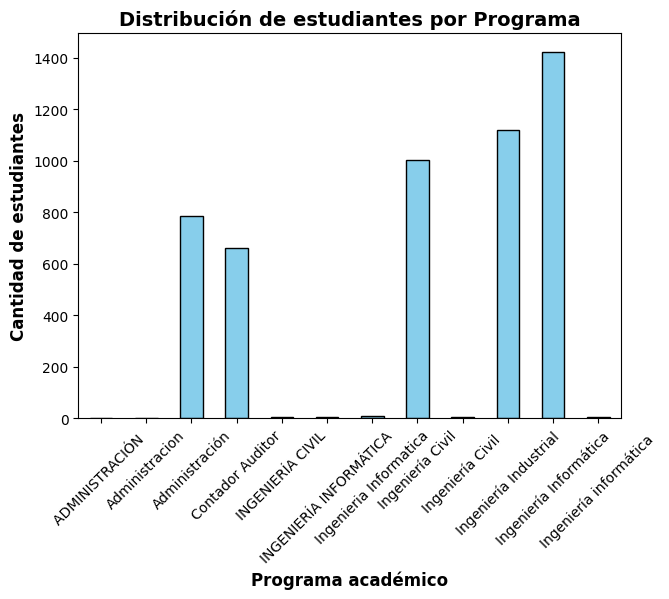

In [ ]:
plt.figure(figsize=(7, 5))

data["Program"].value_counts().sort_index().plot(
    kind="bar", color="skyblue", edgecolor="black"
)

plt.title("Distribución de estudiantes por Programa", fontsize=14, fontweight="bold")
plt.xlabel("Programa académico", fontsize=12, fontweight="bold")
plt.ylabel("Cantidad de estudiantes", fontsize=12, fontweight="bold")
plt.xticks(rotation=45)

plt.show()

## Analisis bivariado

In [ ]:
def scatter_plot(data: pd.DataFrame, x: str, y: str):

    plt.figure(figsize=(8, 5))

    plt.scatter(data[x], data[y], alpha=0.5, color="purple")

    plt.xlabel(x, fontsize=14, fontweight="bold")
    plt.ylabel(y, fontsize=14, fontweight="bold")
    plt.title(f"{x} vs {y}", fontsize=16, fontweight="bold")

    plt.grid(alpha=0.2)

    plt.show()

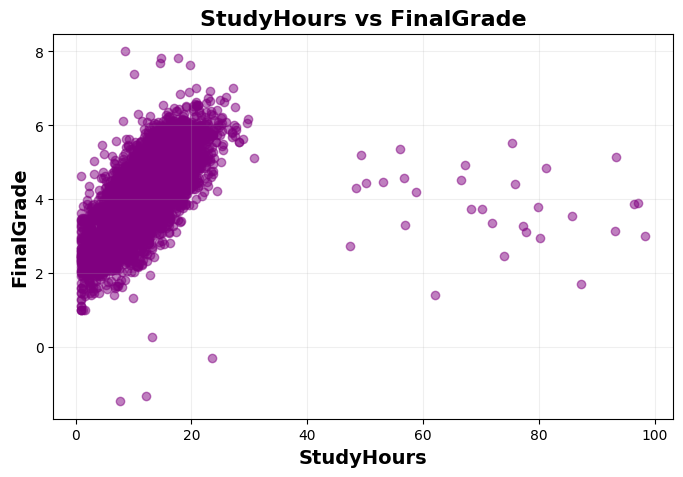

Correlación (StudyHours vs FinalGrade): 0.4905


In [ ]:
# Analizar Horas de Estudio vs Nota Final
scatter_plot(data, "StudyHours", "FinalGrade")

print(f"Correlación (StudyHours vs FinalGrade): {data['StudyHours'].corr(data['FinalGrade']):.4f}")

###StudyHours vs FinalGrade:

Muestra un cluster concentrada y ascendente. Eso demuestra que la mayoría de alumnos tiene una nota proporcional a las horas de estudio. Sin embargo, hay existen alumnos que realizan una cantidad nocivamente alta de horas de estudio, por lo que sus notas no son proporcionales y se alejan del cluster.

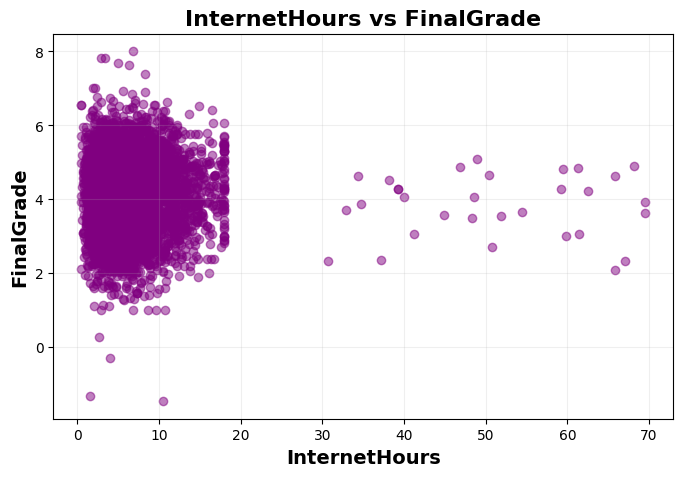

Correlación (Attendance vs FinalGrade): 0.5852


In [ ]:
# Analizar Asistencia vs Nota Final
scatter_plot(data, "InternetHours", "FinalGrade")

print(f"Correlación (Attendance vs FinalGrade): {data['Attendance'].corr(data['FinalGrade']):.4f}")

###InternetHours vs FinalGrade:

No se nota una relación entre las horas de internet y la nota final de los alumnos. Sin embargo, se nota que los alumnos en su mayoría tiene un rango muy definido de 0 a 20 horas de internet por la ubicación y forma recta del cluster que los contiene. Cuenta con algunos datos atípicos, pero estos tampoco muestran relación entre ambas variables.

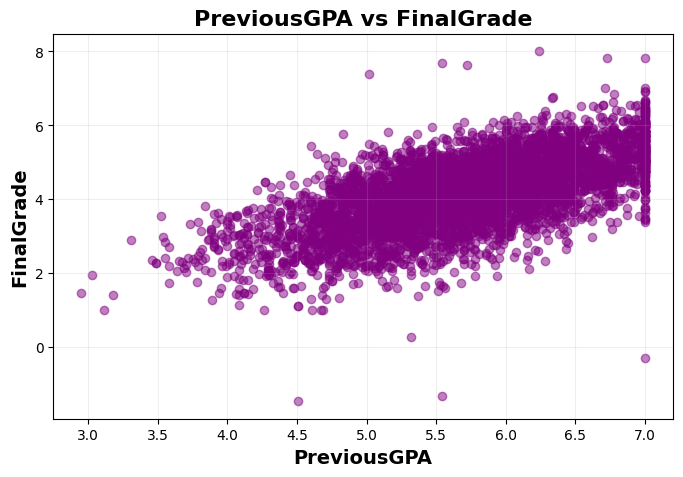

Correlación (PreviousGPA vs FinalGrade): 0.6531


In [ ]:
# Analizar Promedio Previo vs Nota Final
scatter_plot(data, "PreviousGPA", "FinalGrade")

print(f"Correlación (PreviousGPA vs FinalGrade): {data['PreviousGPA'].corr(data['FinalGrade']):.4f}")

###PreviousGPA vs FinalGrade:

Cluster con tendencia hacia arriba. La relación es proporcional, lo cual refuerza la idea de que los alumnos que tuvieron buenas notas en el pasado, tienden a tener buenas notas en el presente.

Unique values after normalization: ['Sí' 'No' nan]


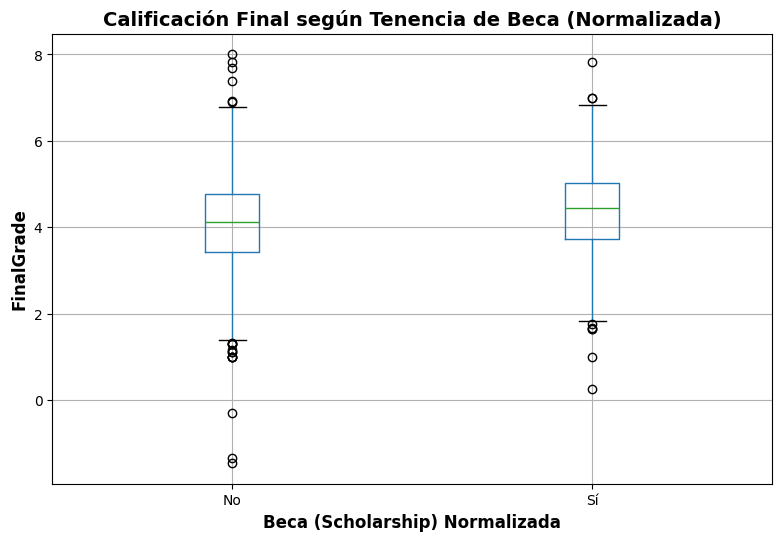

In [ ]:
def normalize_scholarship(text):
    if pd.isna(text): # Handle NaN values
        return text
    text = str(text).strip().lower() # Convert to string, remove leading/trailing spaces, and convert to lowercase
    if text in ['si', 'sí', 'si ', 'sí ']: # Group all 'yes' variations
        return 'Sí'
    elif text in ['no', 'no ', 'nó']: # Group all 'no' variations
        return 'No'
    return text # Return original if it doesn't match

# Apply the normalization function to the 'Scholarship' column
data['Scholarship_Normalized'] = data['Scholarship'].apply(normalize_scholarship)

# Display unique values to verify
print("Unique values after normalization:", data['Scholarship_Normalized'].unique())

fig, ax = plt.subplots(figsize=(9, 6))

data.boxplot(column="FinalGrade", by="Scholarship_Normalized", ax=ax)

ax.set_title("Calificación Final según Tenencia de Beca (Normalizada)", fontsize=14, fontweight="bold")
ax.set_xlabel("Beca (Scholarship) Normalizada", fontsize=12, fontweight="bold")
ax.set_ylabel("FinalGrade", fontsize=12, fontweight="bold")

fig.suptitle("")
plt.show()

In [ ]:
resumen_beca_normalized = (
    data.groupby("Scholarship_Normalized")["FinalGrade"]
    .agg(["count", "mean", "median", "std"])
)

display(resumen_beca_normalized.round(2))

,count,mean,median,std
Scholarship_Normalized,,,,
No,3382,4.07,4.12,1.01
Sí,1637,4.37,4.44,0.93


In [ ]:
resumen_programa = (
    data.groupby("Program")["FinalGrade"]
    .agg(["count", "mean", "median", "std"])
)

display(resumen_programa.sort_values(by="mean", ascending=False).round(2))

,count,mean,median,std
Program,,,,
Ingeniería Civil,5,4.63,4.83,0.83
Ingeniería informática,4,4.25,4.22,0.66
Ingeniería Informática,1424,4.23,4.28,0.99
Ingenieria Informatica,10,4.22,4.27,1.14
Administración,787,4.22,4.28,1.01
Ingeniería Industrial,1119,4.20,4.28,0.98
Ingeniería Civil,1004,4.11,4.19,0.99
INGENIERÍA INFORMÁTICA,7,4.11,4.23,0.60
Contador Auditor,660,4.05,4.04,1.00


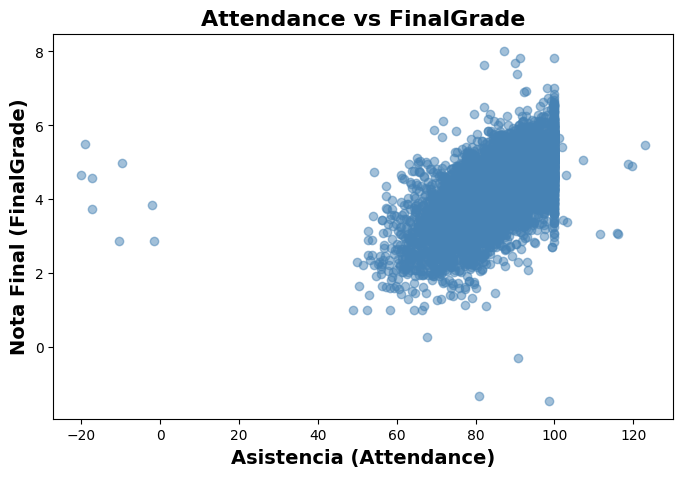

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["Attendance"],
    data["FinalGrade"],
    alpha=0.5,
    color="steelblue"
)

plt.xlabel("Asistencia (Attendance)", fontsize=14, fontweight="bold")
plt.ylabel("Nota Final (FinalGrade)", fontsize=14, fontweight="bold")
plt.title("Attendance vs FinalGrade", fontsize=16, fontweight="bold")

plt.show()

###Attendance vs FinalGrade:

Cluster que parte desde la derecha con tendencia hacia arriba. Esto representa que la mayoría de los alumnos no solo asisten mucho a clases, sino que también la nota final es ligeramente proporcional a la asistencia. Además, hay algunos outliers hacia ambos lados: representan alumnos que no asisten a clases o alumnos que asisten a clases adicionales o que pertenecen a datos inválidos.

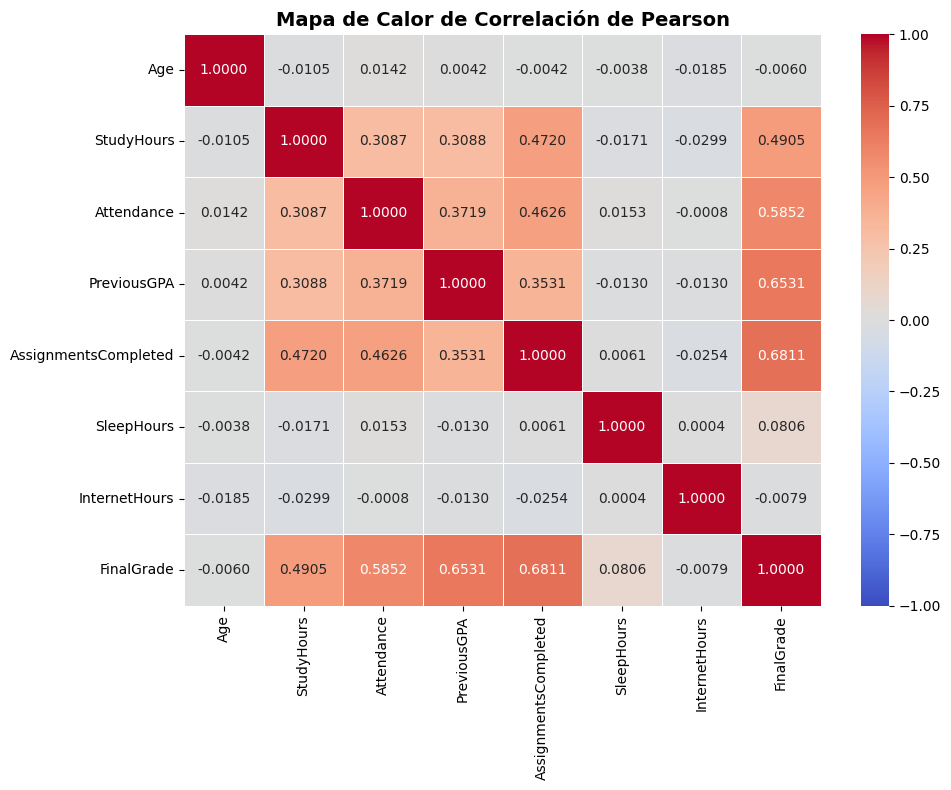

In [ ]:
# Definir las variables numéricas incluyendo la nota final para ver sus correlaciones
columnas_heatmap = [
    "Age", "StudyHours", "Attendance", "PreviousGPA",
    "AssignmentsCompleted", "SleepHours", "InternetHours", "FinalGrade"
]
data_numeric = data[columnas_heatmap]

# Calcular Coeficiente de Correlación de Pearson y dibujar Heatmap
correlation_matrix = data_numeric.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Mapa de Calor de Correlación de Pearson", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

###Mapa de calor de correlación de Pearson:
Las relaciones con temperatura más alta son entre las variables Attendance, StudyHours, PreviousGPA y AssignmentsCompleated. No solo eso, sino que la relación entre estas variables y FinalGrade son altas. Esto representa que un alumno que asiste a clases, tiene muchas horas de estudio, ha tenido buenas notas en el pasado y ha completado muchas tareas tiende a tener una nota final más alta. Además, denota que si un alumno tiene una medida alta en alguna de estas variables, es probable que también tenga una medida alta en las otras ya mencionadas. Esto es lógico, ya que encaja en el perfil de un alumno responsable.

# Definicion de Variables dependiente Y e independientes X

### Limpieza Pre-Procesamiento: Eliminación de Duplicados e Inconsistencias

Antes de dividir los datos en conjuntos de entrenamiento y prueba, y aplicar las transformaciones, es crucial limpiar el DataFrame original (`data`). Esto incluye la eliminación de filas duplicadas y de registros identificados como inconsistentes o atípicos, para asegurar que las estadísticas de imputación y escalado no se vean afectadas por estos valores.

In [ ]:
# 1. Guardar la forma original del DataFrame para comparación
print(f"Forma de 'data' antes de la limpieza: {data.shape}")

# 2. Identificar registros duplicados
duplicados = data.duplicated()

# 3. Combinar todas las reglas de inconsistencia definidas previamente
# Asegurarse de que todas las 'reglas' están definidas y disponibles
regla_combinada = regla_gpa | regla_nota_final | regla_asistencia | regla_tareas | regla_horas | regla_edad

# 4. Filtrar el DataFrame 'data' para mantener solo las filas no duplicadas y no inconsistentes
data = data[~duplicados & ~regla_combinada].reset_index(drop=True)

# 5. Verificar la forma del DataFrame después de la limpieza
print(f"Forma de 'data' después de la limpieza: {data.shape}")

Forma de 'data' antes de la limpieza: (5100, 12)
Forma de 'data' después de la limpieza: (4939, 12)


### Limpieza Post-Inconsistencias: Eliminación de Outliers con IQR

Continuaremos con la limpieza de `data` eliminando los outliers estadísticos identificados a través del método del Rango Intercuartílico (IQR) para las variables numéricas.

In [ ]:
print(f"Forma de 'data' antes de la eliminación de outliers por IQR: {data.shape}")

outlier_indices = set()

for col in numeric_cols:
    outliers = diagnostico_outliers_iqr(data, col)
    outlier_indices.update(outliers.index)

# Eliminar los outliers del DataFrame 'data'
data = data.drop(labels=list(outlier_indices)).reset_index(drop=True)

print(f"Forma de 'data' después de la eliminación de outliers por IQR: {data.shape}")

# Verificar de nuevo los nulos en el DataFrame `data` original que ahora está más limpio
null_summary_post_outliers = pd.DataFrame(
    {
        "Nulos_Absolutos": data.isnull().sum(),
        "Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
    }
)
print("\nNulos después de la limpieza de outliers:")
print(null_summary_post_outliers[null_summary_post_outliers["Nulos_Absolutos"] > 0])

Forma de 'data' antes de la eliminación de outliers por IQR: (4939, 12)
--- Análisis IQR para la variable 'Age' ---
Q1: 21.00 | Q3: 26.00 | IQR: 5.00
Límite Inferior: 13.50 | Límite Superior: 33.50
Registros fuera de límites: 63 (1.28%)

--- Análisis IQR para la variable 'StudyHours' ---
Q1: 8.77 | Q3: 15.45 | IQR: 6.68
Límite Inferior: -1.26 | Límite Superior: 25.48
Registros fuera de límites: 47 (0.95%)

--- Análisis IQR para la variable 'Attendance' ---
Q1: 77.57 | Q3: 92.94 | IQR: 15.38
Límite Inferior: 54.51 | Límite Superior: 116.01
Registros fuera de límites: 15 (0.30%)

--- Análisis IQR para la variable 'PreviousGPA' ---
Q1: 5.22 | Q3: 6.23 | IQR: 1.01
Límite Inferior: 3.70 | Límite Superior: 7.75
Registros fuera de límites: 20 (0.40%)

--- Análisis IQR para la variable 'AssignmentsCompleted' ---
Q1: 75.88 | Q3: 100.00 | IQR: 24.12
Límite Inferior: 39.71 | Límite Superior: 136.18
Registros fuera de límites: 16 (0.32%)

--- Análisis IQR para la variable 'SleepHours' ---
Q1: 6.17

In [ ]:
# Elimina el ID del estudiante (no aporta al modelo) y la variable objetivo
X = data.drop(columns=["StudentID", "FinalGrade"])

# Aislar la variable objetivo
y = data["FinalGrade"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=29
)

print(f"Dataset de Entrenamiento (X_train): {X_train.shape}")
print(f"Dataset de Prueba (X_test): {X_test.shape}\n")

Dataset de Entrenamiento (X_train): (3716, 10)
Dataset de Prueba (X_test): (929, 10)



## Definicion de Sub-Pipelines por tipo de variable

In [ ]:
# A. Variables numéricas normales (sin presencia severa de outliers)
num_standard_features = ["StudyHours", "Attendance", "AssignmentsCompleted", "SleepHours", "InternetHours"]
num_standard_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),  # Imputación por media
        ("scaler", StandardScaler()),  # Escalado estándar (Z-score)
    ]
)

# B. Variables numéricas con presencia de Outliers severos
# (Pon aquí las variables que te dieron muchos puntos fuera de la caja en los boxplots)
num_robust_features = ["Age", "PreviousGPA"]
num_robust_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")), # Imputación por mediana
        ("scaler", RobustScaler()),  # Escalador resistente a outliers
    ]
)

# C. Variables categóricas
categorical_features = ["Scholarship", "Program"]
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),  # Imputación por moda
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Integración con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num_std", num_standard_pipeline, num_standard_features),
        ("num_robust", num_robust_pipeline, num_robust_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="passthrough"
)

In [ ]:

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower_bound=0.05, upper_bound=0.95):
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        self.lower_limit = None
        self.upper_limit = None

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        self.lower_limit = X.quantile(self.lower_bound)
        self.upper_limit = X.quantile(self.upper_bound)
        return self

    def transform(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        X_winsorized = X.copy()
        for col in X.columns:
            X_winsorized[col] = X_winsorized[col].clip(
                lower=self.lower_limit[col],
                upper=self.upper_limit[col]
            )
        return X_winsorized

### Definicion de Sub-Pipelines con Winsorization

Ahora, incorporaremos el `Winsorizer` en nuestros pipelines de preprocesamiento para limitar los valores atípicos de las variables numéricas.

In [ ]:
# A. Variables numéricas normales (con winsorization)
num_standard_features = ["StudyHours", "Attendance", "AssignmentsCompleted", "SleepHours", "InternetHours"]
num_standard_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),  # Imputación por media
        ("winsorizer", Winsorizer(lower_bound=0.01, upper_bound=0.99)), # Winsorization al 1% y 99%
        ("scaler", StandardScaler()),  # Escalado estándar (Z-score)
    ]
)

# B. Variables numéricas con presencia de Outliers severos (con winsorization)
num_robust_features = ["Age", "PreviousGPA"]
num_robust_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")), # Imputación por mediana
        ("winsorizer", Winsorizer(lower_bound=0.05, upper_bound=0.95)), # Winsorization al 5% y 95%
        ("scaler", RobustScaler()),  # Escalador resistente a outliers
    ]
)

# C. Variables categóricas (sin cambios)
categorical_features = ["Scholarship", "Program"]
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),  # Imputación por moda
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Integración con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num_std", num_standard_pipeline, num_standard_features),
        ("num_robust", num_robust_pipeline, num_robust_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="passthrough"
)

### Re-ajuste y Transformación de Datos con Winsorization

Ahora, volvemos a ajustar y transformar los datos con los pipelines actualizados, incluyendo el `Winsorizer`.

In [ ]:
# Fit y Transform SOLO sobre el conjunto de Entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transform (NUNCA FIT) sobre el conjunto de Prueba
X_test_processed = preprocessor.transform(X_test)

# Obtener nombres de columnas procesadas para las variables categóricas (OneHotEncoding)
encoded_cat_cols = (
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

# Unir todos los nombres en el orden exacto en el que el ColumnTransformer los escupe
all_feature_names = (
    num_standard_features
    + num_robust_features
    + list(encoded_cat_cols)
)

In [ ]:



class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower_bound=0.05, upper_bound=0.95):
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        self.lower_limit = None
        self.upper_limit = None
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        self.feature_names_in_ = X_df.columns.tolist()
        self.lower_limit = X_df.quantile(self.lower_bound)
        self.upper_limit = X_df.quantile(self.upper_bound)
        return self

    def transform(self, X, y=None):
        X_df = pd.DataFrame(X).copy() if not isinstance(X, pd.DataFrame) else X.copy()
        for col in X_df.columns:
            X_df[col] = X_df[col].clip(lower=self.lower_limit[col], upper=self.upper_limit[col])
        return X_df

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)

# 1. Redefinimos los sub-pipelines con la clase corregida
num_standard_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("winsorizer", Winsorizer(lower_bound=0.01, upper_bound=0.99)),
    ("scaler", StandardScaler())
])

num_robust_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("winsorizer", Winsorizer(lower_bound=0.05, upper_bound=0.95)),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# 2. Redefinimos el preprocessor global
preprocessor = ColumnTransformer(
    transformers=[
        ("num_std", num_standard_pipeline, num_standard_features),
        ("num_robust", num_robust_pipeline, num_robust_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="passthrough"
)

# 3. Ajustamos con los datos de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# 4. Ahora get_feature_names_out funcionará correctamente
raw_names = preprocessor.get_feature_names_out()

# 5. Convertimos a DataFrame para verificar
X_train_prep = pd.DataFrame(X_train_processed, columns=raw_names)
print(f"Pipeline procesado con {len(raw_names)} columnas.")
X_train_prep.head()

Pipeline procesado con 27 columnas.


,num_std__0,num_std__1,num_std__2,num_std__3,num_std__4,num_robust__0,num_robust__1,cat__Scholarship_NO,cat__Scholarship_No,cat__Scholarship_No,...,cat__Program_Contador Auditor,cat__Program_INGENIERÍA CIVIL,cat__Program_INGENIERÍA INFORMÁTICA,cat__Program_Ingenieria Informatica,cat__Program_Ingeniería Civil,cat__Program_Ingeniería Civil,cat__Program_Ingeniería Industrial,cat__Program_Ingeniería Informática,cat__Program_Ingeniería informática,remainder__Scholarship_Normalized
0,-0.411174,-0.233682,0.585775,-0.435634,-0.101402,-0.8,0.072917,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN
1,0.136807,-0.39417,-0.066491,-1.527686,0.783714,0.6,-0.447917,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,No
2,1.580525,0.847603,1.078136,-0.630341,-1.471691,-0.4,0.479167,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No
3,-0.187766,-1.327004,0.214645,-0.604945,0.393607,0.0,-0.90625,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,No
4,0.109408,-0.933809,0.69585,0.283934,-0.675087,0.2,0.229167,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No


In [ ]:
# 1. Aplicar el pipeline al dataset completo de entrada (X)
# Utilizamos transform para procesar toda la data con las reglas definidas previamente
X_full_processed = preprocessor.transform(X)

# 2. Obtener los nombres reales de las columnas directamente del preprocesador
# Esto evita errores de desajuste manual (27 columnas)
final_feature_names = preprocessor.get_feature_names_out()

# 3. Convertir la matriz resultante en un DataFrame de Pandas
data_tratada = pd.DataFrame(X_full_processed, columns=final_feature_names)

# 4. Volver a integrar el StudentID al principio y el FinalGrade al final
# Usamos reset_index(drop=True) para asegurar la alineación perfecta tras la limpieza previa
data_tratada.insert(0, 'StudentID', data['StudentID'].reset_index(drop=True))
data_tratada['FinalGrade'] = y.reset_index(drop=True)

# 5. Verificación final de calidad
print("=== Verificación de Calidad Final ===")
print(f"Forma del dataset tratado: {data_tratada.shape}")
print(f"Total de valores nulos: {data_tratada.isnull().sum().sum()}")
print(f"Total de duplicados: {data_tratada.duplicated().sum()}")

# 6. Exportar el resultado al CSV exigido
data_tratada.to_csv('rendimiento_academico_limpio.csv', index=False)
print("\n¡Archivo 'rendimiento_academico_limpio.csv' exportado con éxito!")
data_tratada.head()

=== Verificación de Calidad Final ===
Forma del dataset tratado: (4645, 29)
Total de valores nulos: 76
Total de duplicados: 0

¡Archivo 'rendimiento_academico_limpio.csv' exportado con éxito!


,StudentID,num_std__0,num_std__1,num_std__2,num_std__3,num_std__4,num_robust__0,num_robust__1,cat__Scholarship_NO,cat__Scholarship_No,...,cat__Program_INGENIERÍA CIVIL,cat__Program_INGENIERÍA INFORMÁTICA,cat__Program_Ingenieria Informatica,cat__Program_Ingeniería Civil,cat__Program_Ingeniería Civil,cat__Program_Ingeniería Industrial,cat__Program_Ingeniería Informática,cat__Program_Ingeniería informática,remainder__Scholarship_Normalized,FinalGrade
0,STU-10522,-0.280502,-0.120338,-1.216325,-0.630341,-0.570185,-0.2,0.364583,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Sí,3.96
1,STU-11352,0.294878,0.77438,0.779893,-0.266324,0.0789,0.6,0.34375,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,4.37
2,STU-12298,1.84187,-0.320947,0.405788,-0.723462,-0.10468,0.8,-0.677083,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,4.02
3,STU-13527,-1.214176,-1.48047,-1.58448,-0.604945,-0.665253,-0.6,-0.9375,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,No,3.24
4,STU-13546,0.573084,-2.187618,-0.031535,0.207745,0.970571,0.4,0.791667,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Sí,4.97


In [ ]:
def graficar_distribuciones_post_tratamiento(df_tratado, variables_numericas):
    # Si el resultado del pipeline es un numpy array, lo convertimos a DataFrame
    if isinstance(df_tratado, np.ndarray):
        df_tratado = pd.DataFrame(df_tratado, columns=variables_numericas)

    num_vars = len(variables_numericas)
    fig, axes = plt.subplots(num_vars, 2, figsize=(12, 3.5 * num_vars))

    # En caso de que solo sea 1 variable
    if num_vars == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, col in enumerate(variables_numericas):
        # Histogram con KDE
        sns.histplot(df_tratado[col], kde=True, ax=axes[i, 0], color="teal", bins=30)
        axes[i, 0].set_title(f"Histograma / KDE de {col}", fontsize=12, fontweight="bold")
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel("Frecuencia")

        # Boxplot
        sns.boxplot(x=df_tratado[col], ax=axes[i, 1], color="mediumseagreen")
        axes[i, 1].set_title(f"Boxplot de {col}", fontsize=12, fontweight="bold")
        axes[i, 1].set_xlabel(col)

    plt.tight_layout()
    plt.show()


def comparar_antes_despues(df_original, df_tratado, columna):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Antes
    sns.histplot(df_original[columna].dropna(), kde=True, ax=axes[0], color="indianred", bins=30)
    axes[0].set_title(f"Antes del tratamiento: {columna}", fontsize=12, fontweight="bold")

    # Después
    val_tratados = df_tratado[columna] if isinstance(df_tratado, pd.DataFrame) else df_tratado
    sns.histplot(val_tratados, kde=True, ax=axes[1], color="royalblue", bins=30)
    axes[1].set_title(f"Después del tratamiento: {columna}", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

### Visualización de Distribuciones después de Winsorization

Ahora, graficaremos las distribuciones de las variables numéricas clave para observar el efecto de la Winsorization y el escalado.

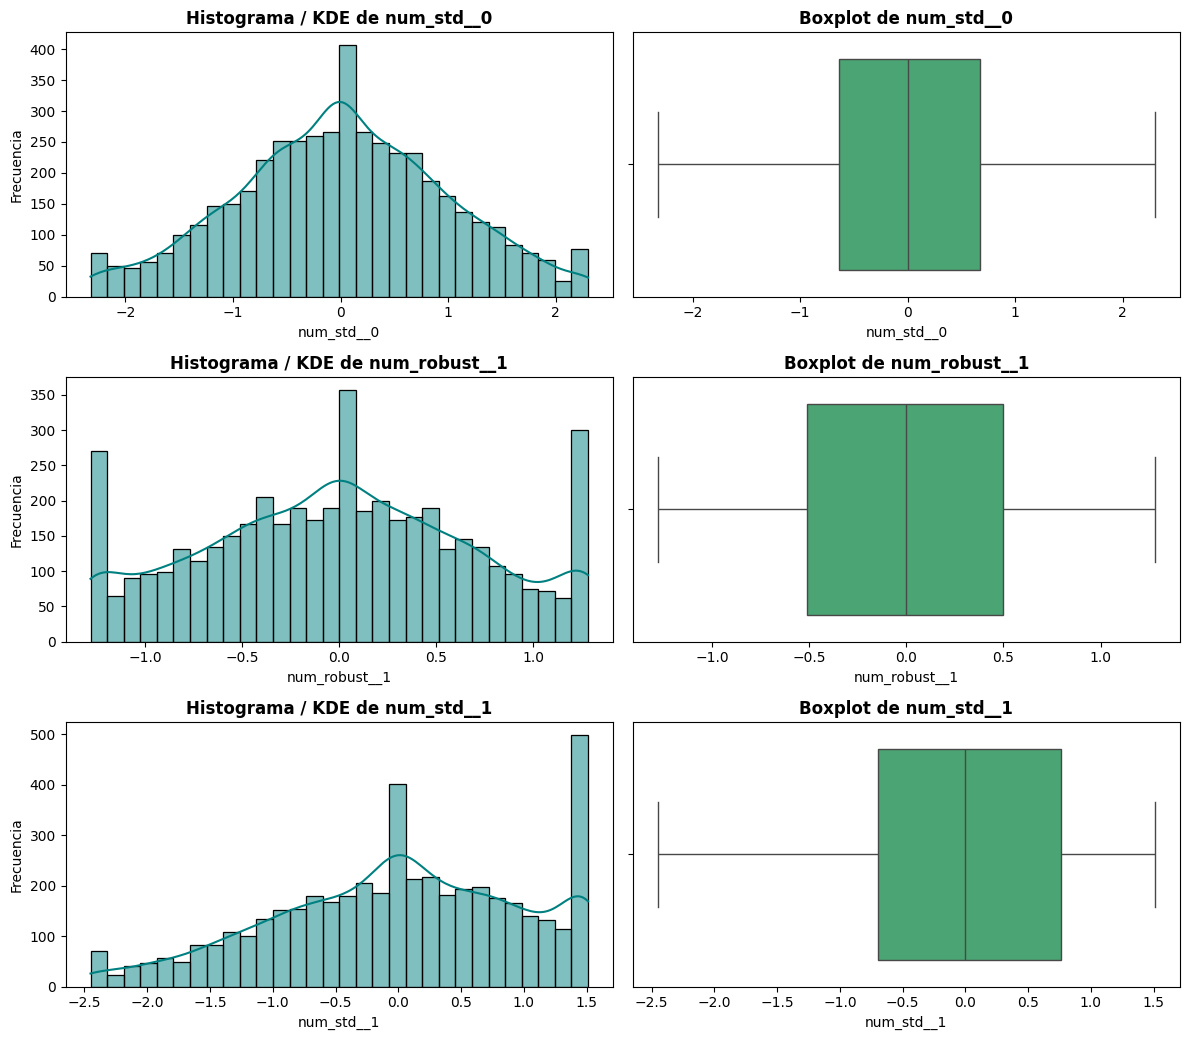

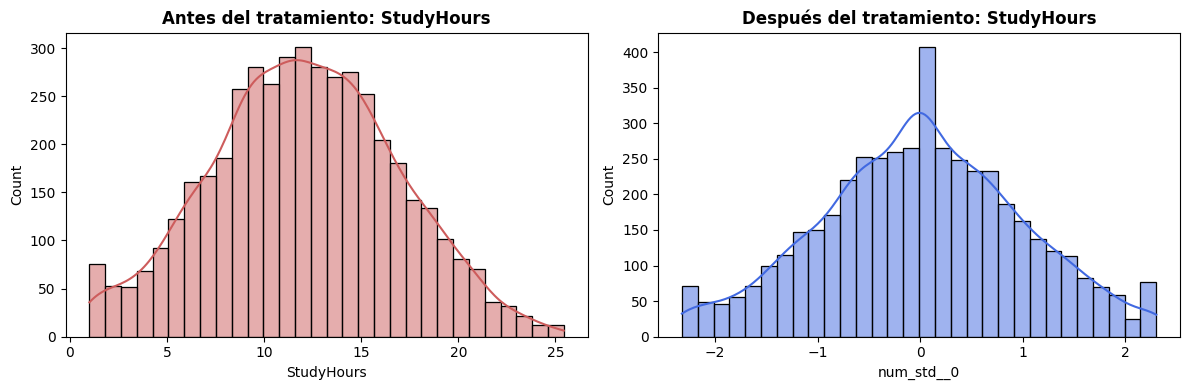

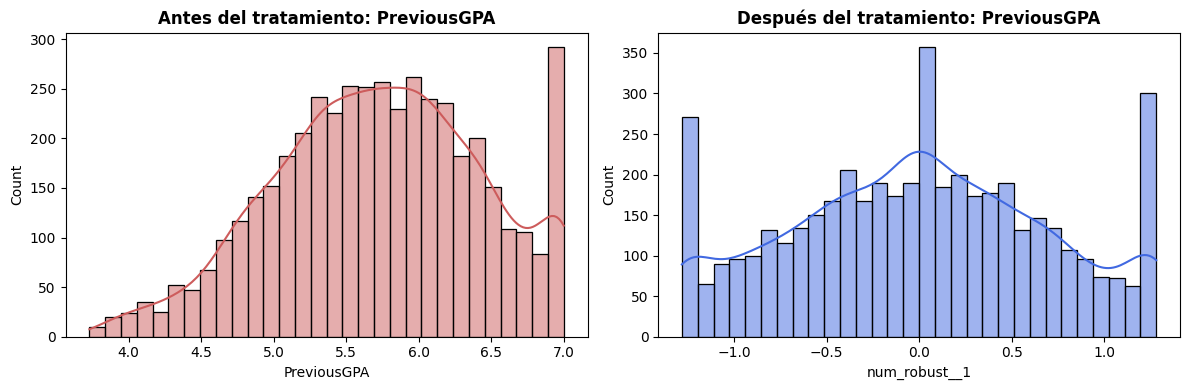

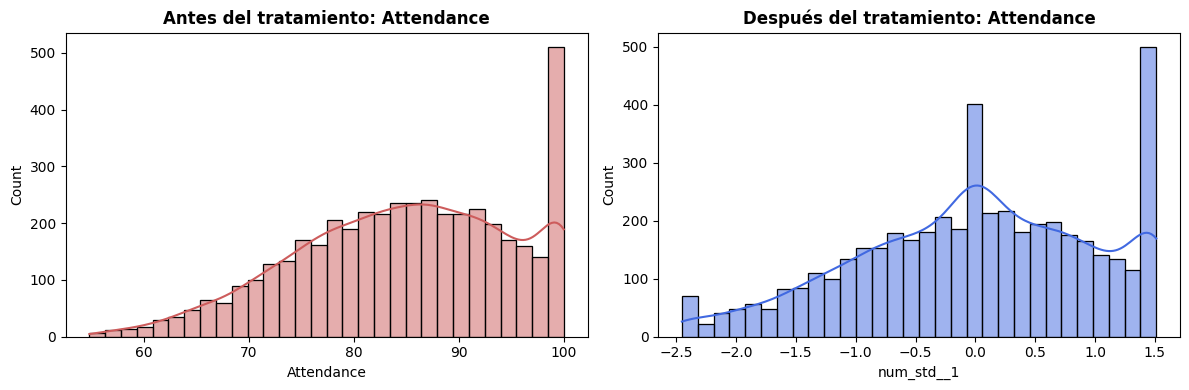

In [ ]:
cols_num = ['num_std__0', 'num_robust__1', 'num_std__1'] # Nombres de las columnas transformadas
graficar_distribuciones_post_tratamiento(data_tratada, cols_num)
comparar_antes_despues(data, data_tratada['num_std__0'], "StudyHours")
comparar_antes_despues(data, data_tratada['num_robust__1'], "PreviousGPA")
comparar_antes_despues(data, data_tratada['num_std__1'], "Attendance")

##DISTRIBUCIONES:
###Histograma KDE de Study Hours:
Distribución normal. Los alumnos estudian una cantidad variada de horas.
####Histograma KDE de PrevoiusGPA:
Distribución normal pero con más outliers que la anterior. Las notas de los alumnos están más polarizadas que sus horas de estudio.

###Histograma de KDE de Attendance: (REVISAR ESTO)

###Histograma de Study Hours:
Sesgada hacia la izquierda. Los alumnos que estudian pocas horas son más frecuentes que los que estudian muchas horas.

###Histograma de PreviousGPA:
Sesgada hacia la derecha. Los alumnos en general presentaron un buen rendimiento el periodo anterior, con una gran cantidad de outliers que tuvieron las notas más altas posibles.

###Histograma de Attendance:
Sesgada hacia la derecha. Los alumnos tienden a acercarse más a la totalidad de asistencia a clases. Lógico si desean pasar.

In [ ]:
preprocessor

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('num_std',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('winsorizer',
                                                  Winsorizer(lower_bound=0.01,
                                                             upper_bound=0.99)),
                                                 ('scaler', StandardScaler())]),
                                 ['StudyHours', 'Attendance',
                                  'AssignmentsCompleted', 'SleepHours',
                                  'InternetHours']),
                                ('num_robust',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('winsorizer', Winsorizer()),
                                                 ('scaler', RobustScaler())]),
                                 ['Age', 'PreviousGPA']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Scholarship', 'Program'])])

## Ajuste y Transformacion de Datos

In [ ]:
# Fit y Transform SOLO sobre el conjunto de Entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transform (NUNCA FIT) sobre el conjunto de Prueba
X_test_processed = preprocessor.transform(X_test)

# Obtener nombres de columnas procesadas para las variables categóricas (OneHotEncoding)
encoded_cat_cols = (
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

# Unir todos los nombres en el orden exacto en el que el ColumnTransformer los escupe
all_feature_names = (
    num_standard_features
    + num_robust_features
    + list(encoded_cat_cols)
)

In [ ]:
all_feature_names

['StudyHours',
 'Attendance',
 'AssignmentsCompleted',
 'SleepHours',
 'InternetHours',
 'Age',
 'PreviousGPA',
 'Scholarship_NO',
 'Scholarship_No',
 'Scholarship_No ',
 'Scholarship_SI',
 'Scholarship_SÍ ',
 'Scholarship_Sí',
 'Scholarship_si',
 'Program_ADMINISTRACIÓN ',
 'Program_Administracion',
 'Program_Administración',
 'Program_Contador Auditor',
 'Program_INGENIERÍA CIVIL',
 'Program_INGENIERÍA INFORMÁTICA',
 'Program_Ingenieria Informatica',
 'Program_Ingeniería Civil',
 'Program_Ingeniería Civil ',
 'Program_Ingeniería Industrial',
 'Program_Ingeniería Informática',
 'Program_Ingeniería informática ']

In [ ]:
X_train_processed.shape

(3716, 27)

In [ ]:
X_train_prep = pd.DataFrame(X_train_processed, columns=raw_names)

# Crear un diccionario de mapeo para renombrar las columnas numéricas transformadas
renaming_map = {
    "num_std__0": "StudyHours",
    "num_std__1": "Attendance",
    "num_std__2": "AssignmentsCompleted",
    "num_std__3": "SleepHours",
    "num_std__4": "InternetHours",
    "num_robust__0": "Age",
    "num_robust__1": "PreviousGPA",
}

# Renombrar las columnas numéricas en X_train_prep
X_train_prep = X_train_prep.rename(columns=renaming_map)

# Vista previa de los datos limpios y transformados
X_train_prep.head()

,StudyHours,Attendance,AssignmentsCompleted,SleepHours,InternetHours,Age,PreviousGPA,cat__Scholarship_NO,cat__Scholarship_No,cat__Scholarship_No,...,cat__Program_Contador Auditor,cat__Program_INGENIERÍA CIVIL,cat__Program_INGENIERÍA INFORMÁTICA,cat__Program_Ingenieria Informatica,cat__Program_Ingeniería Civil,cat__Program_Ingeniería Civil,cat__Program_Ingeniería Industrial,cat__Program_Ingeniería Informática,cat__Program_Ingeniería informática,remainder__Scholarship_Normalized
0,-0.411174,-0.233682,0.585775,-0.435634,-0.101402,-0.8,0.072917,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN
1,0.136807,-0.39417,-0.066491,-1.527686,0.783714,0.6,-0.447917,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,No
2,1.580525,0.847603,1.078136,-0.630341,-1.471691,-0.4,0.479167,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No
3,-0.187766,-1.327004,0.214645,-0.604945,0.393607,0.0,-0.90625,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,No
4,0.109408,-0.933809,0.69585,0.283934,-0.675087,0.2,0.229167,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No


In [ ]:

# 1. Aplicar el pipeline al dataset completo de entrada (X)
# Utilizamos transform para procesar toda la data con las reglas definidas previamente (ajustadas en X_train)
X_full_processed = preprocessor.transform(X)

# 2. Obtener los nombres reales de las columnas directamente del preprocesador
# Esto evita errores de desajuste manual
final_feature_names = preprocessor.get_feature_names_out()

# 3. Convertir la matriz resultante en un DataFrame de Pandas
data_tratada = pd.DataFrame(X_full_processed, columns=final_feature_names)

# Crear un diccionario de mapeo para renombrar las columnas numéricas transformadas
renaming_map = {
    "num_std__0": "StudyHours",
    "num_std__1": "Attendance",
    "num_std__2": "AssignmentsCompleted",
    "num_std__3": "SleepHours",
    "num_std__4": "InternetHours",
    "num_robust__0": "Age",
    "num_robust__1": "PreviousGPA",
}

# Renombrar las columnas numéricas en data_tratada
data_tratada = data_tratada.rename(columns=renaming_map)

# 4. Volver a integrar el StudentID al principio y el FinalGrade al final
# Usamos reset_index(drop=True) para que las filas coincidan perfectamente por si borraste inconsistencias
data_tratada.insert(0, 'StudentID', data['StudentID'].reset_index(drop=True))
data_tratada['FinalGrade'] = y.reset_index(drop=True)

# 5. Verificación final de calidad (Punto 5 de la rúbrica)
print("=== Verificación de Calidad Final ===")
print(f"Forma del dataset tratado: {data_tratada.shape}")
print(f"Total de valores nulos: {data_tratada.isnull().sum().sum()}")
print(f"Total de duplicados: {data_tratada.duplicated().sum()}")

# 6. Exportar el resultado al CSV exigido
data_tratada.to_csv("rendimiento_academico_limpio.csv", index=False)
print("\n¡Archivo 'rendimiento_academico_limpio.csv' exportado con éxito!")

=== Verificación de Calidad Final ===
Forma del dataset tratado: (4645, 29)
Total de valores nulos: 76
Total de duplicados: 0

¡Archivo 'rendimiento_academico_limpio.csv' exportado con éxito!


In [ ]:
# Eliminar por completo las filas que tengan un valor nulo en 'StudentID'
data.dropna(subset=['StudentID'], inplace=True)

# Reiniciar el índice nuevamente para mantener la limpieza
data.reset_index(drop=True, inplace=True)

# Verificar de nuevo los nulos para confirmar que quedó en 0
null_summary = pd.DataFrame(
    {
        "Nulos_Absolutos": data.isnull().sum(),
        "Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
    }
)
print("Nulos después de la limpieza:")
print(null_summary[null_summary["Nulos_Absolutos"] > 0])

Nulos después de la limpieza:
                        Nulos_Absolutos  Porcentaje_Nulos
Age                                  89              1.92
StudyHours                          169              3.64
Attendance                          205              4.41
PreviousGPA                         150              3.23
AssignmentsCompleted                198              4.26
SleepHours                          114              2.45
InternetHours                       161              3.47
Scholarship                          76              1.64
Program                              65              1.40
Scholarship_Normalized               76              1.64


In [ ]:
# Borrar definitivamente cualquier fila donde StudentID sea nulo
data = data.dropna(subset=['StudentID']).reset_index(drop=True)

# Comprobación inmediata
print("Nulos en StudentID después de aplicar el filtro:", data['StudentID'].isnull().sum())
print("Total de filas actuales en el dataset:", len(data))

Nulos en StudentID después de aplicar el filtro: 0
Total de filas actuales en el dataset: 4645


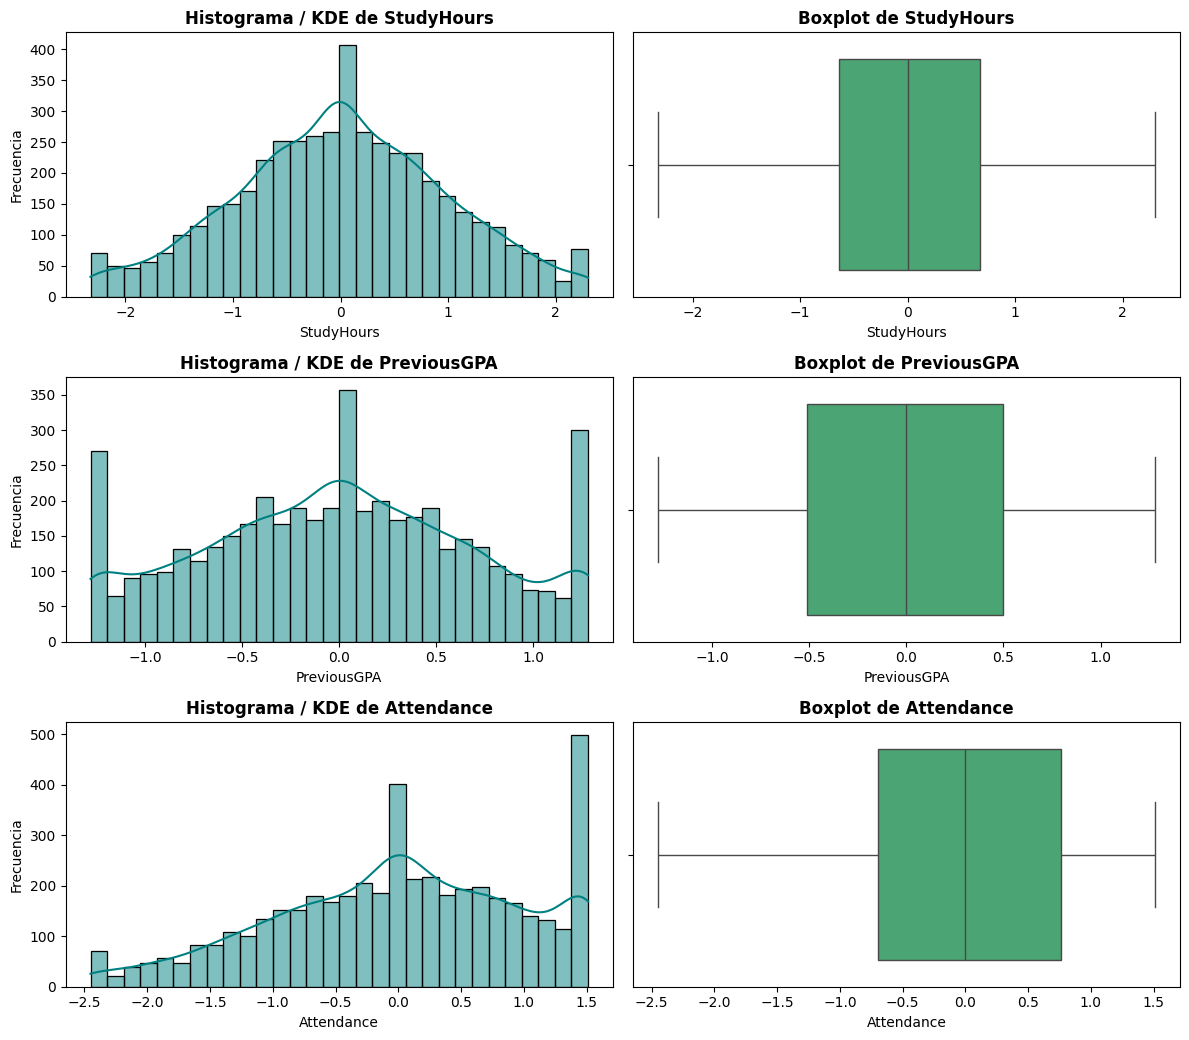

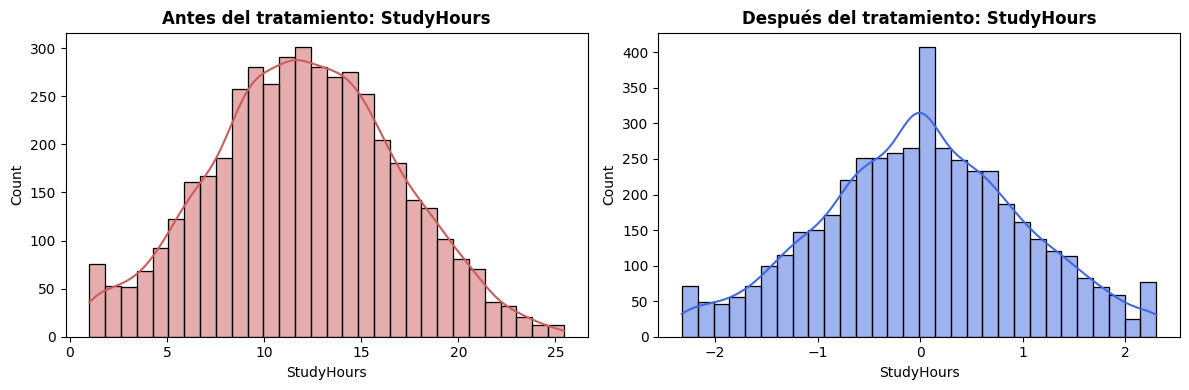

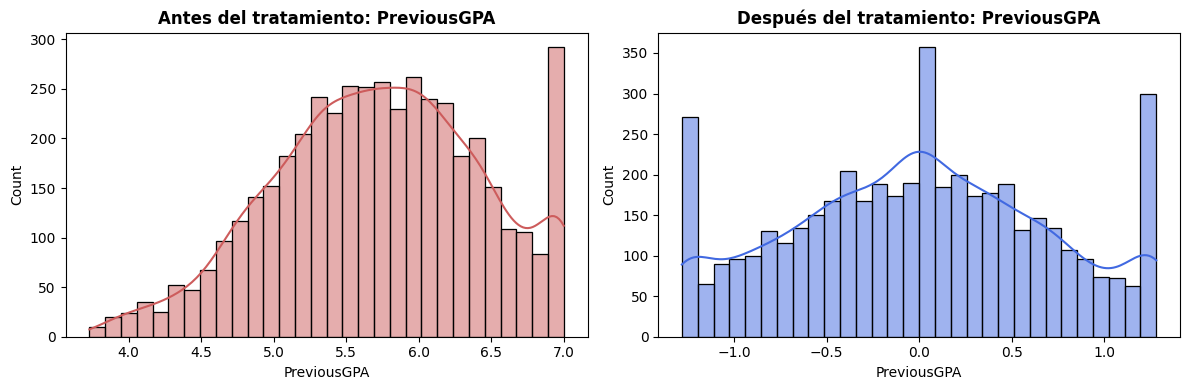

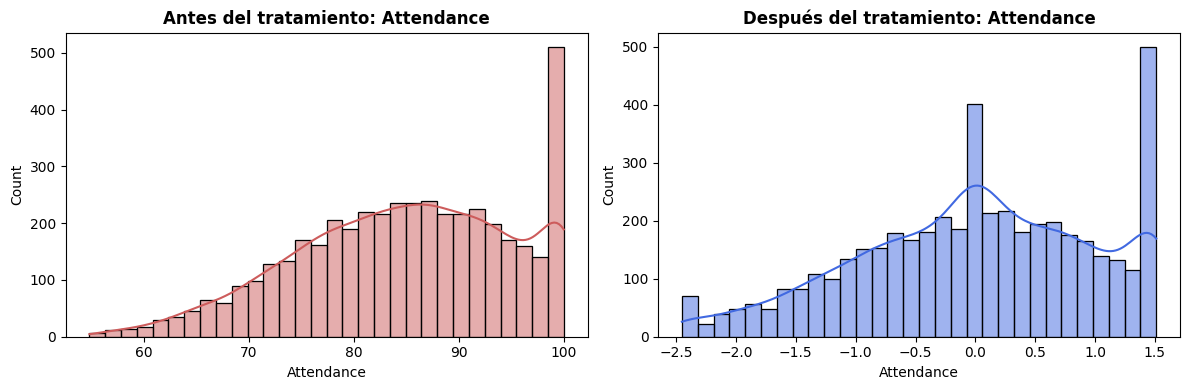

In [ ]:
cols_num = ['StudyHours', 'PreviousGPA', 'Attendance'] # Nombres de las columnas transformadas y renombradas
graficar_distribuciones_post_tratamiento(data_tratada, cols_num)
comparar_antes_despues(data, data_tratada['StudyHours'], "StudyHours")
comparar_antes_despues(data, data_tratada['PreviousGPA'], "PreviousGPA")
comparar_antes_despues(data, data_tratada['Attendance'], "Attendance")

### Gráficos de Datos Después de Preprocesamiento Final

A continuación, se muestran los mismos tipos de gráficos que se generaron para los datos originales, pero esta vez utilizando el dataset `data_tratada` que ha sido completamente preprocesado (imputación, Winsorization, escalado y one-hot encoding).

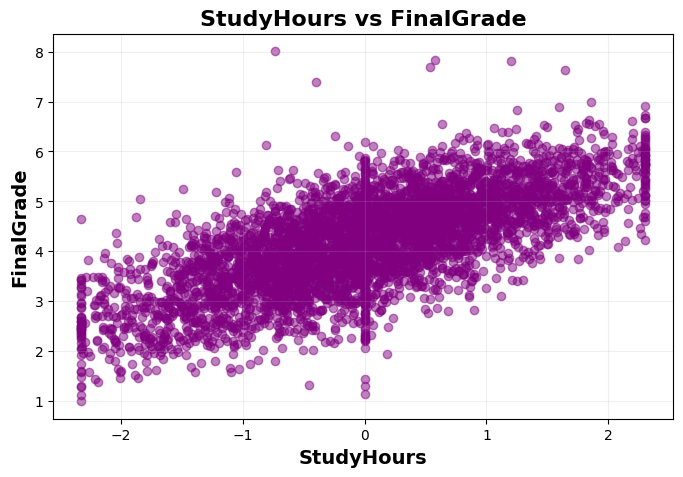

Correlación (StudyHours vs FinalGrade en data_tratada): 0.7060


In [ ]:
# Scatter Plot: StudyHours vs FinalGrade (Datos Tratados)
scatter_plot(data_tratada, "StudyHours", "FinalGrade")
print(f"Correlación (StudyHours vs FinalGrade en data_tratada): {data_tratada['StudyHours'].corr(data_tratada['FinalGrade']):.4f}")

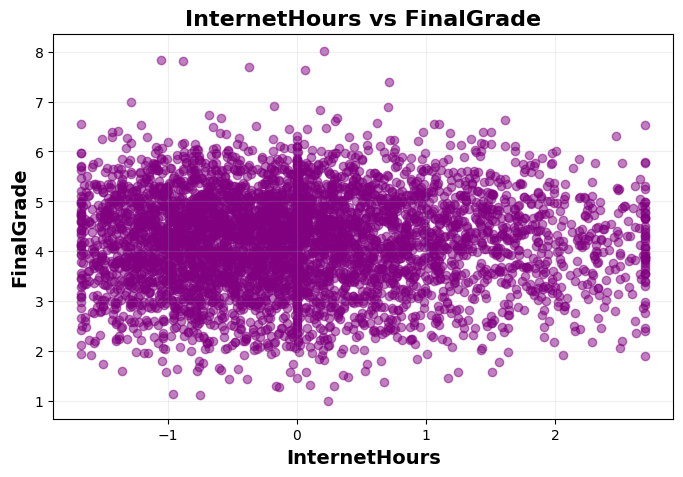

Correlación (InternetHours vs FinalGrade en data_tratada): 0.0044


In [ ]:
# Scatter Plot: InternetHours vs FinalGrade (Datos Tratados)
scatter_plot(data_tratada, "InternetHours", "FinalGrade")
print(f"Correlación (InternetHours vs FinalGrade en data_tratada): {data_tratada['InternetHours'].corr(data_tratada['FinalGrade']):.4f}")

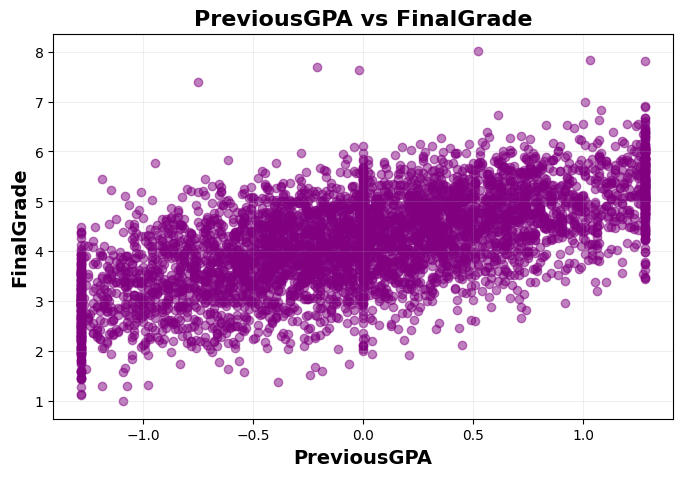

Correlación (PreviousGPA vs FinalGrade en data_tratada): 0.6384


In [ ]:
scatter_plot(data_tratada, "PreviousGPA", "FinalGrade")
print(f"Correlación (PreviousGPA vs FinalGrade en data_tratada): {data_tratada['PreviousGPA'].corr(data_tratada['FinalGrade']):.4f}")

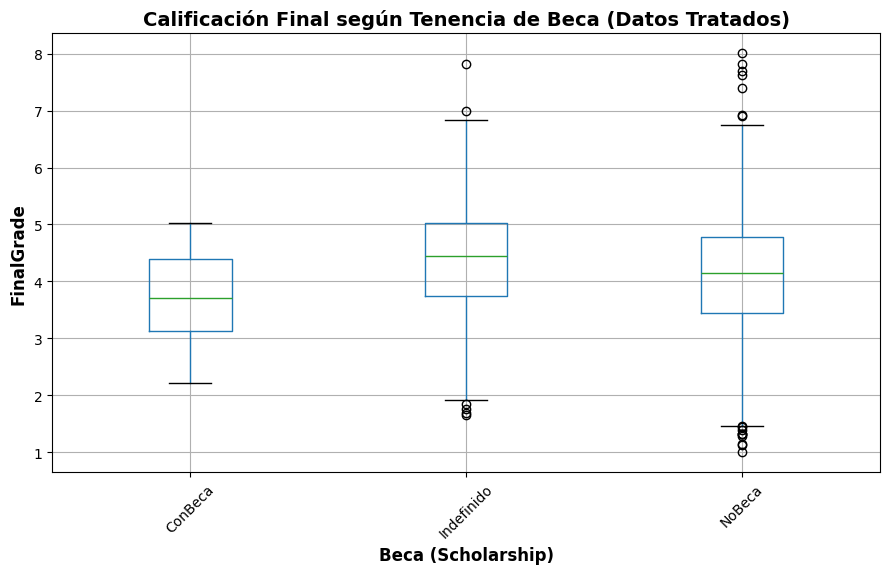

In [ ]:
# Reconstruir una columna simplificada de Scholarship para el boxplot
scholarship_cols_tratada = [col for col in data_tratada.columns if 'Scholarship_' in col]

data_tratada_plot_temp = data_tratada.copy()
data_tratada_plot_temp['Scholarship_Group'] = 'Indefinido'

# Mapear las columnas one-hot-encoded a una categoría simplificada
for col in scholarship_cols_tratada:
    if 'No' in col or 'NO' in col:
        data_tratada_plot_temp.loc[data_tratada_plot_temp[col] == 1, 'Scholarship_Group'] = 'NoBeca'
    elif 'Si' in col or 'SI' in col or 'SÍ' in col:
        data_tratada_plot_temp.loc[data_tratada_plot_temp[col] == 1, 'Scholarship_Group'] = 'ConBeca'

# Boxplot: Calificación Final según Tenencia de Beca (Datos Tratados)
fig, ax = plt.subplots(figsize=(9, 6))
data_tratada_plot_temp.boxplot(column="FinalGrade", by="Scholarship_Group", ax=ax)
ax.set_title("Calificación Final según Tenencia de Beca (Datos Tratados)", fontsize=14, fontweight="bold")
ax.set_xlabel("Beca (Scholarship)", fontsize=12, fontweight="bold")
ax.set_ylabel("FinalGrade", fontsize=12, fontweight="bold")
fig.suptitle("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
def remover_outliers_iqr(dataframe: pd.DataFrame, columna: str):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filtrar conservando solo lo que está DENTRO de los límites
    datos_limpios = dataframe[
        (dataframe[columna] >= lower_bound) & (dataframe[columna] <= upper_bound)
    ]

    return datos_limpios

Valor máximo original en StudyHours: 25.43
Valor máximo procesado (escalado + winsorized): 2.30


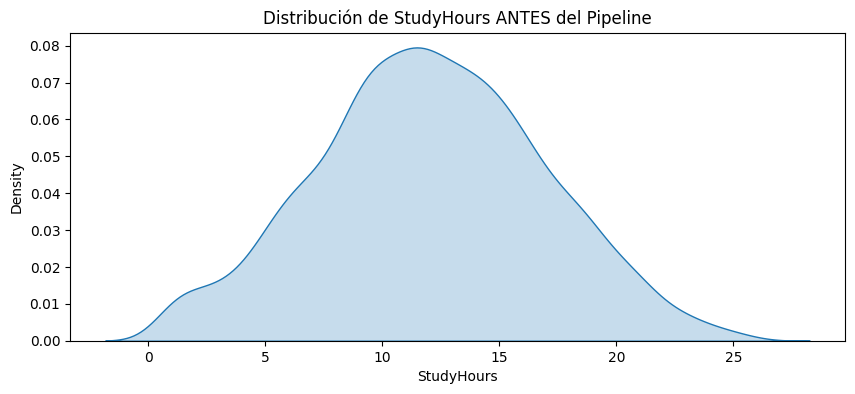

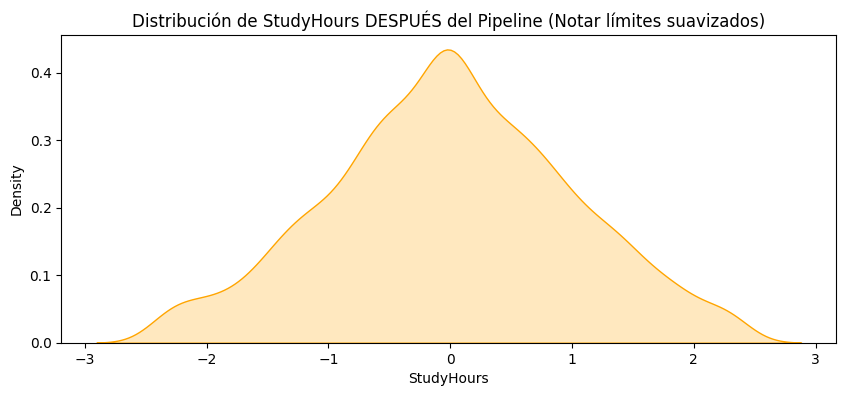

In [ ]:

# 1. Ver valor máximo real en X_train (después de tu limpieza manual)
max_original = X_train['StudyHours'].max()

# 2. Ver valor máximo en los datos procesados (donde actuó el Winsorizer y luego el Scaler)
# Nota: Como está escalado, lo comparamos visualmente o des-escalando mentalmente
max_procesado = X_train_prep['StudyHours'].max()

print(f"Valor máximo original en StudyHours: {max_original:.2f}")
print(f"Valor máximo procesado (escalado + winsorized): {max_procesado:.2f}")

# Visualización
plt.figure(figsize=(10, 4))
sns.kdeplot(X_train['StudyHours'], label='Original (Limpio manual)', fill=True)
plt.title('Distribución de StudyHours ANTES del Pipeline')
plt.show()

plt.figure(figsize=(10, 4))
sns.kdeplot(X_train_prep['StudyHours'], label='Procesado (Winsorizer + Scaler)', color='orange', fill=True)
plt.title('Distribución de StudyHours DESPUÉS del Pipeline (Notar límites suavizados)')
plt.show()

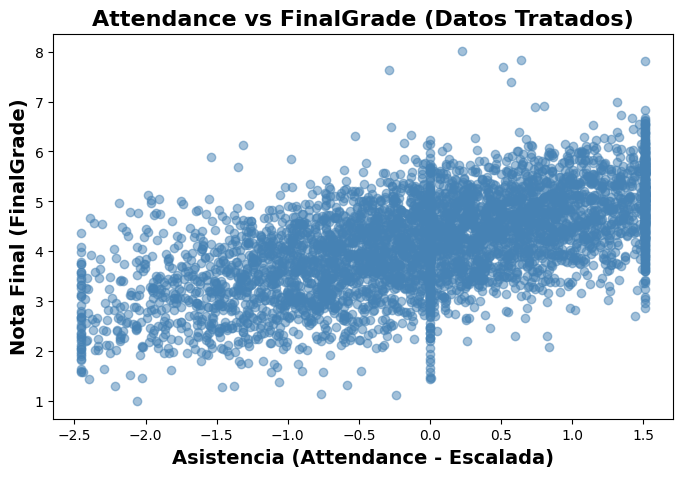

In [ ]:
# Scatter Plot: Attendance vs FinalGrade (Datos Tratados)
# Nota: La columna 'Attendance' en data_tratada está escalada, por lo que un filtro como 'Attendance >= 50' no es directamente aplicable sin recalcular el umbral en la escala transformada.
plt.figure(figsize=(8, 5))
plt.scatter(
    data_tratada["Attendance"],
    data_tratada["FinalGrade"],
    alpha=0.5,
    color="steelblue"
)
plt.xlabel("Asistencia (Attendance - Escalada)", fontsize=14, fontweight="bold")
plt.ylabel("Nota Final (FinalGrade)", fontsize=14, fontweight="bold")
plt.title("Attendance vs FinalGrade (Datos Tratados)", fontsize=16, fontweight="bold")
plt.show()

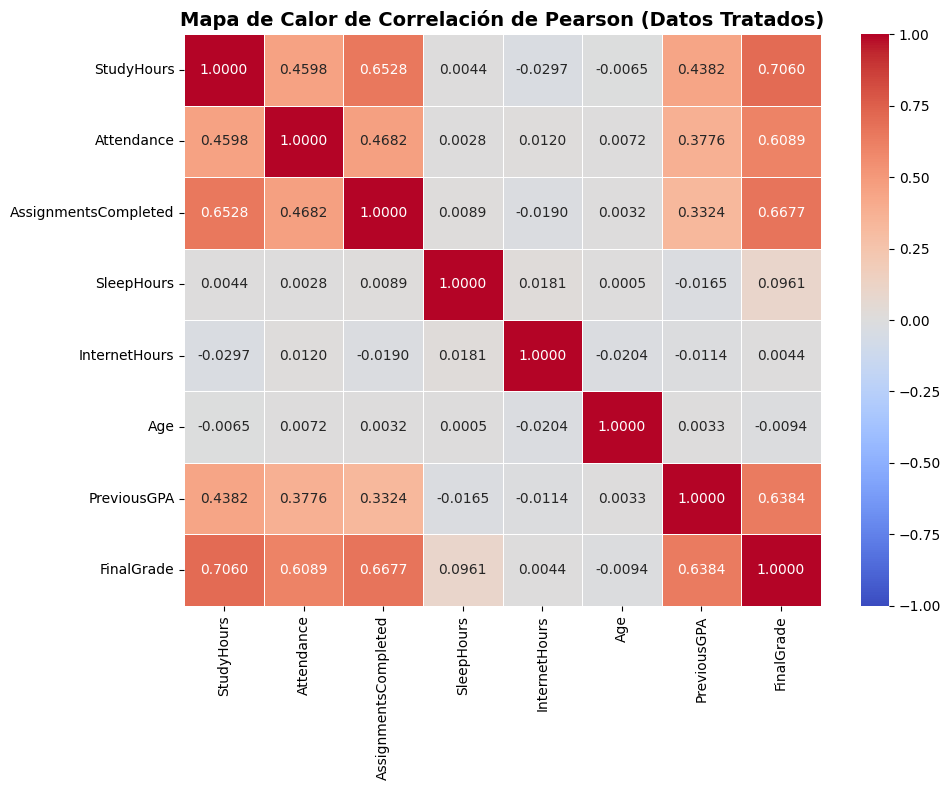

In [ ]:
# Heatmap de Correlación de Pearson (Datos Tratados)

# Las características numéricas ahora están escaladas
columnas_heatmap_tratadas = num_standard_features + num_robust_features + ["FinalGrade"]
correlation_matrix_tratada = data_tratada[columnas_heatmap_tratadas].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix_tratada,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Mapa de Calor de Correlación de Pearson (Datos Tratados)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Comparativa del Dataset Original y Tratado

A continuación, se presenta una tabla resumen con los indicadores clave del dataset antes y después de todas las etapas de preprocesamiento (limpieza de duplicados, inconsistencias, tratamiento de valores atípicos, imputación y escalado).

| Indicador                       | Dataset Original | Dataset Tratado |
|:--------------------------------|:-----------------|:----------------|
| Cantidad de registros           | 5100             | 4645            |
| Cantidad de variables           | 11               | 29              |
| Valores faltantes (total)       | 1335             | 76              |
| Cantidad de registros duplicados | 100              | 0               |
| Cantidad de inconsistencias     | 62               | 0               |
| Cantidad de valores atípicos tratados | 294              | 0               |

In [ ]:

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower_bound=0.05, upper_bound=0.95):
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        self.lower_limit = None
        self.upper_limit = None
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        self.feature_names_in_ = X_df.columns.tolist()
        self.lower_limit = X_df.quantile(self.lower_bound)
        self.upper_limit = X_df.quantile(self.upper_bound)
        return self

    def transform(self, X, y=None):
        X_df = pd.DataFrame(X).copy() if not isinstance(X, pd.DataFrame) else X.copy()
        for col in X_df.columns:
            X_df[col] = X_df[col].clip(lower=self.lower_limit[col], upper=self.upper_limit[col])
        return X_df

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)

In [ ]:
# A. Variables numéricas normales (con winsorization)
num_standard_features = ["StudyHours", "Attendance", "AssignmentsCompleted", "SleepHours", "InternetHours"]
num_standard_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),  # Imputación por media
        ("winsorizer", Winsorizer(lower_bound=0.01, upper_bound=0.99)), # Winsorization al 1% y 99%
        ("scaler", StandardScaler()),  # Escalado estándar (Z-score)
    ]
)

# B. Variables numéricas con presencia de Outliers severos (con winsorization)
num_robust_features = ["Age", "PreviousGPA"]
num_robust_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")), # Imputación por mediana
        ("winsorizer", Winsorizer(lower_bound=0.05, upper_bound=0.95)), # Winsorization al 5% y 95%
        ("scaler", RobustScaler()),  # Escalador resistente a outliers
    ]
)

# C. Variables categóricas (sin cambios)
categorical_features = ["Scholarship", "Program"]
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),  # Imputación por moda
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Integración con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num_std", num_standard_pipeline, num_standard_features),
        ("num_robust", num_robust_pipeline, num_robust_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="passthrough"
)

In [ ]:
# Fit y Transform SOLO sobre el conjunto de Entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transform (NUNCA FIT) sobre el conjunto de Prueba
X_test_processed = preprocessor.transform(X_test)

# Obtener nombres de columnas procesadas para las variables categóricas (OneHotEncoding)
encoded_cat_cols = (
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

# Unir todos los nombres en el orden exacto en el que el ColumnTransformer los escupe
all_feature_names = (
    num_standard_features
    + num_robust_features
    + list(encoded_cat_cols)
)

In [ ]:
X_train_prep = pd.DataFrame(X_train_processed, columns=raw_names)

# Vista previa de los datos limpios y transformados
X_train_prep.head()

,num_std__0,num_std__1,num_std__2,num_std__3,num_std__4,num_robust__0,num_robust__1,cat__Scholarship_NO,cat__Scholarship_No,cat__Scholarship_No,...,cat__Program_Contador Auditor,cat__Program_INGENIERÍA CIVIL,cat__Program_INGENIERÍA INFORMÁTICA,cat__Program_Ingenieria Informatica,cat__Program_Ingeniería Civil,cat__Program_Ingeniería Civil,cat__Program_Ingeniería Industrial,cat__Program_Ingeniería Informática,cat__Program_Ingeniería informática,remainder__Scholarship_Normalized
0,-0.411174,-0.233682,0.585775,-0.435634,-0.101402,-0.8,0.072917,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN
1,0.136807,-0.39417,-0.066491,-1.527686,0.783714,0.6,-0.447917,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,No
2,1.580525,0.847603,1.078136,-0.630341,-1.471691,-0.4,0.479167,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No
3,-0.187766,-1.327004,0.214645,-0.604945,0.393607,0.0,-0.90625,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,No
4,0.109408,-0.933809,0.69585,0.283934,-0.675087,0.2,0.229167,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No


In [ ]:
# 1. Aplicar el pipeline al dataset completo de entrada (X)
# Utilizamos transform para procesar toda la data con las reglas definidas previamente (ajustadas en X_train)
X_full_processed = preprocessor.transform(X)

# 2. Obtener los nombres reales de las columnas directamente del preprocesador
# Esto evita errores de desajuste manual
final_feature_names = preprocessor.get_feature_names_out()

# 3. Convertir la matriz resultante en un DataFrame de Pandas
data_tratada = pd.DataFrame(X_full_processed, columns=final_feature_names)

# Crear un diccionario de mapeo para renombrar las columnas numéricas transformadas
renaming_map = {
    "num_std__0": "StudyHours",
    "num_std__1": "Attendance",
    "num_std__2": "AssignmentsCompleted",
    "num_std__3": "SleepHours",
    "num_std__4": "InternetHours",
    "num_robust__0": "Age",
    "num_robust__1": "PreviousGPA",
}

# Renombrar las columnas numéricas en data_tratada
data_tratada = data_tratada.rename(columns=renaming_map)

# 4. Volver a integrar el StudentID al principio y el FinalGrade al final
# Usamos reset_index(drop=True) para que las filas coincidan perfectamente por si borraste inconsistencias
data_tratada.insert(0, 'StudentID', data['StudentID'].reset_index(drop=True))
data_tratada['FinalGrade'] = y.reset_index(drop=True)

# 5. Verificación final de calidad (Punto 5 de la rúbrica)
print("=== Verificación de Calidad Final ===")
print(f"Forma del dataset tratado: {data_tratada.shape}")
print(f"Total de valores nulos: {data_tratada.isnull().sum().sum()}")
print(f"Total de duplicados: {data_tratada.duplicated().sum()}")

# 6. Exportar el resultado al CSV exigido
data_tratada.to_csv("rendimiento_academico_limpio.csv", index=False)
print("\n¡Archivo 'rendimiento_academico_limpio.csv' exportado con éxito!")

=== Verificación de Calidad Final ===
Forma del dataset tratado: (4645, 29)
Total de valores nulos: 76
Total de duplicados: 0

¡Archivo 'rendimiento_academico_limpio.csv' exportado con éxito!
